# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Aqsa Firdaus
- **Email:** cdcc284d6y0355@student.devacademy.id
- **ID Dicoding:** CDCC284D6Y0355

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah transaksi dan total revenue perusahaan selama tahun 2017 berdasarkan data bulanan?
- Kategori produk apa yang memiliki jumlah transaksi tertinggi dan terendah selama tahun 2017?
- Kota mana yang memiliki jumlah transaksi tertinggi selama tahun 2017?
- Berapa jumlah hari sejak transaksi terakhir pelanggan selama tahun 2017?
- Berapa jumlah transaksi yang dilakukan oleh setiap pelanggan selama tahun 2017?
- Berapa total pengeluaran yang dilakukan oleh setiap pelanggan selama tahun 2017?

## Import Semua Packages/Library yang Digunakan

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

## Data Wrangling

### Gathering Data

In [58]:
# load data customers
customers = pd.read_csv('data/customers_dataset.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [59]:
# load data geolocation
geolocation = pd.read_csv('data/geolocation_dataset.csv')
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [60]:
# load data orders
orders = pd.read_csv('data/orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [61]:
# load data order items
order_items = pd.read_csv('data/order_items_dataset.csv')
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [62]:
# load data order payments
order_payments = pd.read_csv('data/order_payments_dataset.csv')
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [63]:
# load data order reviews
order_reviews = pd.read_csv('data/order_reviews_dataset.csv')
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [64]:
# load data products
products = pd.read_csv('data/products_dataset.csv')
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [65]:
# load data product category name translation
category_translation = pd.read_csv('data/product_category_name_translation.csv')
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [66]:
# load data sellers
sellers = pd.read_csv('data/sellers_dataset.csv')
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**

Dataset yang digunakan adalah E-Commerce Public Dataset yang terdiri dari beberapa tabel, yaitu:

- customers_dataset
- geolocation_dataset
- orders_dataset
- order_items_dataset
- order_payments_dataset
- order_reviews_dataset
- products_dataset
- product_category_name_translation
- sellers_dataset

Dataset ini berisi informasi transaksi e-commerce yang dapat digunakan untuk analisis perilaku pelanggan dan performa bisnis. Akan tetapi, disini saya akan menggunakan beberapa dataset saja yaitu customers_dataset, orders_dataset, order_items_dataset dan product_dataset untuk menjawab pertanyaan bisnis.

### Assessing Data

In [67]:
# menampilkan informasi data customers
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [68]:
# menampilkan duplikasi dan statistik data customers
print('jumlah duplikasi: ', customers.duplicated().sum())
customers.describe()

jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [69]:
# menampilkan informasi data orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [70]:
# menampilkan kolom missing value pada data orders
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [71]:
# menampilkan duplikasi dan statistik data orders
print('jumlah duplikasi: ', orders.duplicated().sum())
orders.describe()

jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [72]:
# menampilkan informasi data order items
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [73]:
# menampilkan duplikasi dan statistik data order items
print('jumlah duplikasi: ', order_items.duplicated().sum())
order_items.describe()

jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [74]:
# menampilkan informasi data product
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [75]:
# menampilkan kolom missing value pada data products
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [76]:
# menampilkan duplikasi dan statistik data products
print('jumlah duplikasi: ', products.duplicated().sum())
products.describe()

jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**

Dari proses penilaian data diatas, didapatkan hasil seperti berikut:

- terdapat kesalahan format tipe data yang seharusnya bertipe datetime dan terdapat missing value di beberapa kolom pada data orders
- terdapat kesalahan tipe data di kolom shipping limit date yang seharusnya bertipe datetime pada data order items
- terdapat missing value di beberapa kolom pada data products

### Cleaning Data

In [77]:
# konversi tipe data ke datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [78]:
# menampilkan kolom order delivered customer date yang kosong atau nat
orders[orders.order_delivered_customer_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [79]:
# memfilter order status hanya "delivered"
orders = orders[orders['order_status'] == 'delivered']

In [80]:
# menambahkan kolom baru delivery time
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

**Insight Data Orders:**

- Seluruh kolom tanggal masih dalam format object dan perlu dikonversi menjadi datetime
- Terdapat missing values pada beberapa kolom terkait proses pengiriman
yang kemungkinan disebabkan oleh order yang belum selesai atau dibatalkan. Oleh karena itu, dilakukan filtering hanya pada order dengan status "delivered" untuk memastikan analisis dilakukan pada data yang valid
- Membuat fitur atau kolom baru yaitu "delivery_time" untuk menghitung waktu pengiriman dalam hitungan hari

In [81]:
# konversi tipe data ke datetime
order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'], errors='coerce'
)

In [82]:
# menambahkan kolom baru total price
order_items['total_price'] = (
    order_items['price'] + order_items['freight_value']
)

**Insight Data Order Items:**

- Kolom shipping_limit_date masih dalam format object dan telah dikonversi menjadi datetime
- Menambahkan kolom total_price untuk merepresentasikan total biaya transaksi (harga produk + ongkos kirim)

In [83]:
# mengisi missing value dengan "unknown"
products['product_category_name'].fillna('unknown', inplace=True)

C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\69665374.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna('unknown', inplace=True)


In [84]:
# mengisi kolom numerik dengan median
num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in num_cols:
    products[col].fillna(products[col].median(), inplace=True)

C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\868382148.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products[col].fillna(products[col].median(), inplace=True)
C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\868382148.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [85]:
# menggabungkan data products dengan data category translation
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [86]:
# membuat kolom baru product volume
products['product_volume'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

**Insight Data Products:**

- Mengatasi missing values pada kolom product_category diisi dengan label "unknown" untuk mempertahankan data dan missing values pada kolom numerik diisi menggunakan median untuk menjaga distribusi data
- Menggabungkan dengan data category_translation untuk mempermudah analisis
- Menambahkan kolom baru berupa volume produk untuk analisis tambahan

## Exploratory Data Analysis (EDA)

In [87]:
# menghitung jumlah customer berdasarkan customer city
customers.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head()

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
Name: customer_id, dtype: int64

In [88]:
# menggabungkan data orders dengan data customers
orders_customers = pd.merge(
    left=orders,
    right=customers,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [89]:
# menampilkan jumlah order id berdasarkan customer city
orders_customers.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).reset_index().head()

,customer_city,order_id
0,sao paulo,15045
1,rio de janeiro,6601
2,belo horizonte,2697
3,brasilia,2071
4,curitiba,1489


In [90]:
# menampilkan jumlah order id berdasarkan customer state
orders_customers.groupby(by="customer_state").order_id.nunique().sort_values(ascending=False).reset_index().head()

,customer_state,order_id
0,SP,40501
1,RJ,12350
2,MG,11354
3,RS,5345
4,PR,4923


In [91]:
# menggabungkan data products dengan data order items
products_order_items = pd.merge(
    left=products,
    right=order_items,
    how="left",
    left_on="product_id",
    right_on="product_id"
)
products_order_items.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,product_volume,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,2240.0,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39,18.30
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,10800.0,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99,265.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,2430.0,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82,87.62
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,2704.0,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54,121.84
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,4420.0,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29,46.19


In [92]:
# menampilkan product dengan harga tertinggi
products_order_items[['product_category_name_english', 'price']].sort_values(by="price", ascending=False).head()

,product_category_name_english,price
20528,housewares,6735.0
73922,computers,6729.0
49503,art,6499.0
71835,small_appliances,4799.0
32232,small_appliances,4690.0


In [110]:
# menggabungkan semua data antara data orders customers dengan data products order items
all_df = pd.merge(
    left=orders_customers,
    right=products_order_items,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df = all_df[all_df['order_purchase_timestamp'].dt.year == 2017]
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,...,product_height_cm,product_width_cm,product_category_name_english,product_volume,order_item_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,8.0,13.0,housewares,1976.0,1,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,...,10.0,20.0,pet_shop,6000.0,1,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,16.0,80bb27c7c16e8f973207a5086ab329e2,...,10.0,65.0,auto,42250.0,1,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,175.26
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,9.0,932afa1e708222e5821dac9cd5db4cae,...,16.0,17.0,auto,4352.0,1,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,75.16
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,9.0,39382392765b6dc74812866ee5ee92a7,...,35.0,15.0,furniture_decor,18375.0,1,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05,35.95


In [111]:
# menghitung jumlah product dan price berdasarkan state
all_df.groupby(by=["customer_state", "product_category_name_english"]).agg({
    "product_id": "count",
    "price": "sum"
})

product_id    price
customer_state product_category_name_english                     
AC             auto                                    4   540.98
               baby                                    3   697.84
               bed_bath_table                          4   567.70
               christmas_supplies                      1    69.90
               computers                               1  1200.00
...                                                  ...      ...
TO             sports_leisure                          8  1468.07
               stationery                              2   246.90
               telephony                               9   263.32
               toys                                    5   648.87
               watches_gifts                          10  1227.42

[1148 rows x 2 columns]

In [112]:
# menghitung jumlah product dan price berdasarkan city
all_df.groupby(by=["customer_city", "product_category_name_english"]).agg({
    "product_id": "count",
    "price": "sum"
})

product_id  price
customer_city       product_category_name_english                   
abadia dos dourados sports_leisure                          1  120.0
abaete              baby                                    1   65.0
                    fashion_bags_accessories                1  449.0
                    garden_tools                            1  135.0
                    health_beauty                           1  208.9
...                                                       ...    ...
zacarias            auto                                    1  143.8
                    housewares                              1   55.0
ze doca             food_drink                              1   65.0
                    garden_tools                            1   39.9
                    musical_instruments                     1  359.0

[15141 rows x 2 columns]

In [113]:
# menampilkan jumlah product yang terjual dan total revenue
product_sales = all_df.groupby('product_category_name_english').agg({
    'product_id': 'count',
    'price': 'sum'
}).rename(columns={
    'product_id': 'quantity_sold',
    'price': 'total_revenue'
}).sort_values(by='quantity_sold', ascending=False)

product_sales.head()

,quantity_sold,total_revenue
product_category_name_english,,
bed_bath_table,5135,490596.92
furniture_decor,4044,324587.60
sports_leisure,3978,435674.14
health_beauty,3581,473833.00
computers_accessories,3010,391786.29


In [114]:
# menampilkan total orders dan total revenue setiap bulan
all_df['order_month'] = all_df['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = all_df.groupby(pd.Grouper(key='order_purchase_timestamp', freq='MS')).agg({
    'order_id': 'count',
    'price': 'sum'
}).rename(columns={
    'order_id': 'total_orders',
    'price': 'total_revenue'
}).reset_index()

monthly_sales.rename(columns={'order_purchase_timestamp': 'order_month'}, inplace=True)

monthly_sales.head()

,order_month,total_orders,total_revenue
0,2017-01-01,913,111798.36
1,2017-02-01,1858,234223.40
2,2017-03-01,2897,359198.85
3,2017-04-01,2569,340669.68
4,2017-05-01,4004,489338.25


In [115]:
# menampilkan total orders berdasarkan customer city
top_city = all_df.groupby('customer_city').agg({
    'order_id': 'count'
}).rename(columns={
    'order_id': 'total_orders'
}).reset_index().sort_values(by='total_orders', ascending=False)

top_city['customer_city'] = top_city['customer_city'].astype(str)
top_city.head()

,customer_city,total_orders
2841,sao paulo,7083
2494,rio de janeiro,3696
345,belo horizonte,1344
426,brasilia,1004
2354,porto alegre,784


In [116]:
all_df.to_csv("all_data.csv", index=False)

**Insight:**
- Harga produk termahal yaitu housewares, computers dan art
- Setiap kota memiliki kebutuhan produk berbeda beda yang mungkin dipengaruhi oleh faktor lingkungan setiap kota
- Produk bed bath table merupakan jumlah penjualan tertinggi namun total revenue tertinggi adalah produk health beauty
- Terjadi fluktuasi penjualan setiap bulan. Beberapa bulan menunjukkan peningkatan signifikan yang mengindikasikan adanya periode peak sales
- Kategori produk bed bath table dan health beauty mendominasi jumlah penjualan, menunjukkan preferensi pelanggan terhadap jenis produk tersebut
- Kota sao paulo memiliki jumlah transaksi yang jauh lebih tinggi dibandingkan kota lainnya, yang menunjukkan potensi pasar utama

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir?


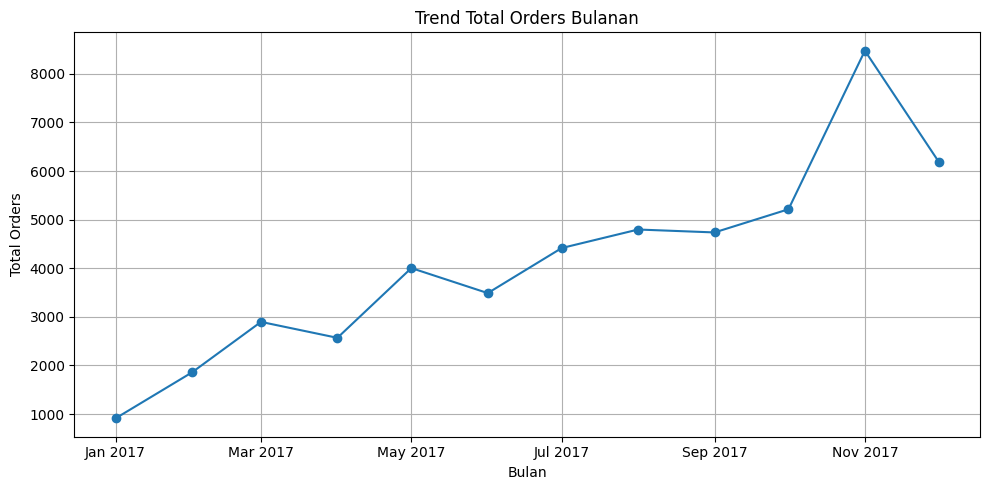

In [117]:
# membuat grafik tren total orders per bulan
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['order_month'],
    monthly_sales['total_orders'],
    marker='o'
)

# format bulan + tahun
plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y')
)

plt.xticks(rotation=0)

# format angka jadi integer (jumlah order)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x)}')
)

plt.title("Trend Total Orders Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Orders")

plt.grid()

plt.tight_layout()
plt.show()

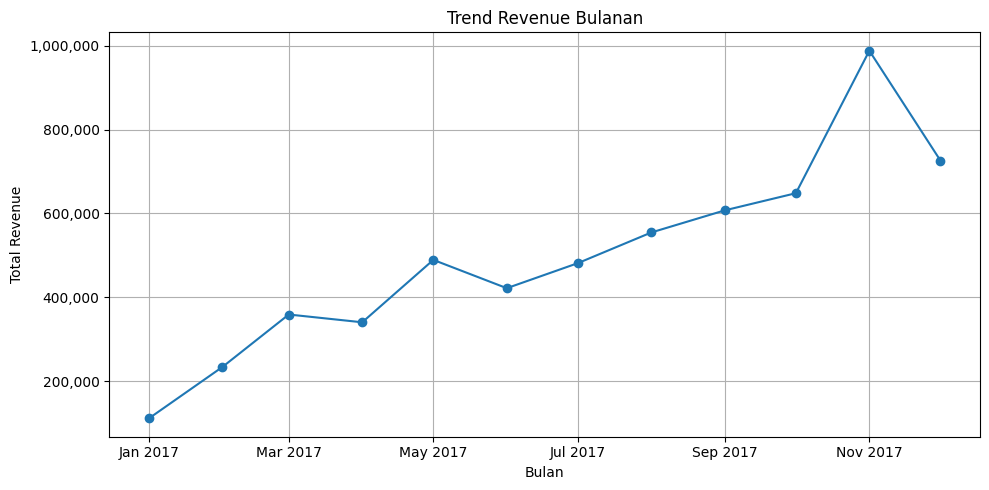

In [118]:
# membuat grafik tren total revenue per bulan
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['order_month'],
    monthly_sales['total_revenue'],
    marker='o'
)

# format bulan + tahun
plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y')
)

plt.xticks(rotation=0)

# format angka revenue biar jelas
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.title("Trend Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")

plt.grid()

plt.tight_layout()
plt.show()

**Insight:**
- Terlihat adanya fluktuasi penjualan setiap bulan dan mulai meningkat pada Maret 2017 hingga mencapai puncak penjualan tertinggi pada November 2017 sebanyak 8 ribu pesanan
- Terdapat periode dengan peningkatan revenue yang sangat signifikan pada November 2017 dengan total sekitar 1 juta pendapatan
- Hal ini menunjukkan adanya pola musiman dalam transaksi pelanggan karena perbedaan yang cukup signifikan setiap bulan

### Pertanyaan 2: Kategori produk apa yang paling banyak dan paling sedikit terjual?


C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\2104559327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="quantity_sold", y="product_category_name_english", data=product_sales.head(5), palette=colors, ax=ax[0])
C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\2104559327.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="quantity_sold", y="product_category_name_english", data=product_sales.sort_values(by="quantity_sold", ascending=True).head(5), palette=colors, ax=ax[1])


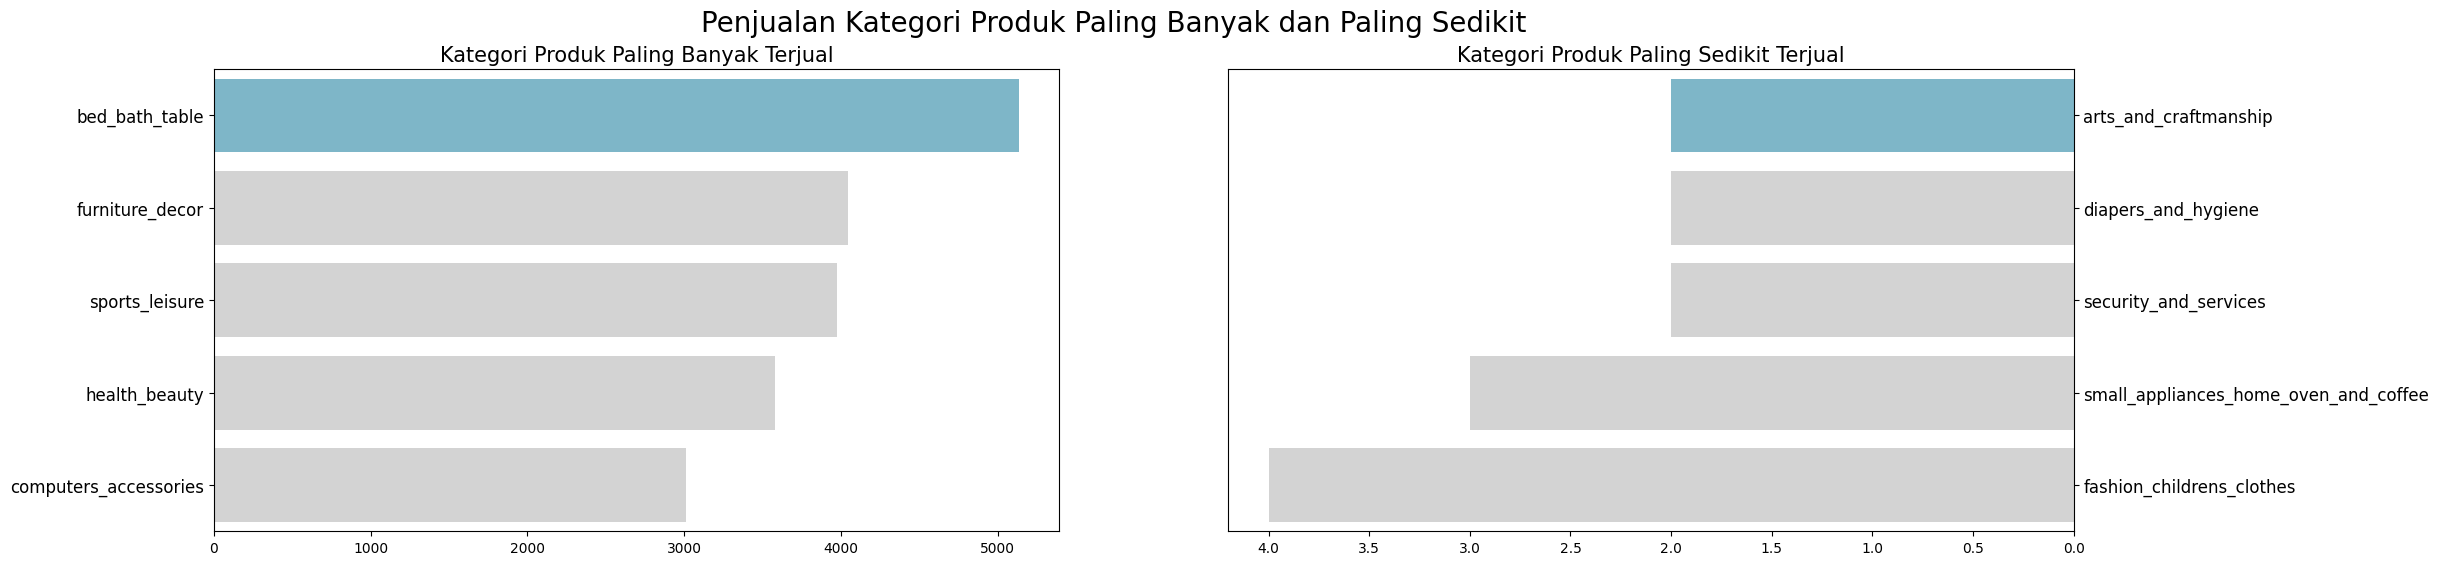

In [119]:
# membuat barchart pernjualan produk kategori paling banyak dan paling sedikit
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="quantity_sold", y="product_category_name_english", data=product_sales.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Kategori Produk Paling Banyak Terjual", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="quantity_sold", y="product_category_name_english", data=product_sales.sort_values(by="quantity_sold", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori Produk Paling Sedikit Terjual", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Penjualan Kategori Produk Paling Banyak dan Paling Sedikit", fontsize=20)
plt.show()

**Insight:**

- Kategori produk bed bath table mendominasi jumlah penjualan dengan total 5 ribu penjualan diikuti dengan kategori produk furniture decor dan sports leisure sehingga dapat menjadi fokus utama strategi pemasaran
- Kategori produk paling sedikit terjual adalah arts and craftmanship yang memungkinkan harus diberikan diskon atau promo supaya produk bisa laris terjual

### Pertanyaan 3: Kota  mana yang memiliki jumlah transaksi tertinggi?


C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\513235167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


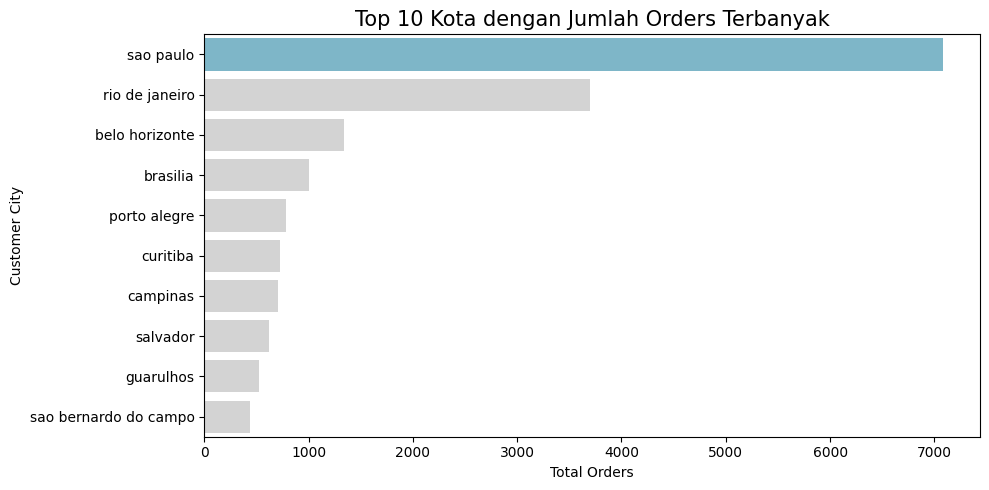

In [120]:
# membuat barchart kota dengan order terbanyak
# ambil top 10 kota
top_10_city = top_city.head(10)

plt.figure(figsize=(10, 5))

colors_ = ["#72BCD4"] + ["#D3D3D3"] * (len(top_10_city) - 1)

sns.barplot(
    x="total_orders",
    y="customer_city",
    data=top_10_city,
    palette=colors_
)

plt.title("Top 10 Kota dengan Jumlah Orders Terbanyak", loc="center", fontsize=15)
plt.xlabel("Total Orders")
plt.ylabel("Customer City")

plt.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

**Insight:**

- Transaksi didominasi oleh kota Sao Paulo dengan total order sebanyak 7 ribu pesanan diikuti oleh kota Rio de Janeiro dan Belo Horizonte
- Hal ini menunjukkan adanya konsentrasi pelanggan di wilayah dengan total pesanan yang cukup sedikit seperti Sao Bernado dan Guarulhos supaya jumlah pesanan bisa meningkat

## RFM Analysis (Pertanyaan 4 - 6)

RFM Analysis merupakan teknik analisis yang digunakan untuk memahami perilaku pelanggan berdasarkan tiga aspek utama, yaitu Recency, Frequency, dan Monetary.

- Recency mengukur seberapa lama sejak pelanggan terakhir melakukan transaksi.
- Frequency mengukur seberapa sering pelanggan melakukan pembelian dalam periode tertentu.
- Monetary mengukur total pengeluaran pelanggan selama periode tersebut.

Tujuan dari analisis ini adalah untuk mengidentifikasi karakteristik pelanggan, seperti pelanggan yang aktif, loyal, dan memiliki kontribusi tinggi terhadap revenue perusahaan.

Dengan memahami perilaku pelanggan melalui RFM, perusahaan dapat menyusun strategi pemasaran yang lebih efektif, seperti meningkatkan retensi pelanggan, memberikan penawaran khusus, serta mengoptimalkan nilai pelanggan dalam jangka panjang.

In [121]:
# Pastikan kolom tanggal sudah datetime
all_df['order_purchase_timestamp'] = pd.to_datetime(all_df['order_purchase_timestamp'])

# Hitung RFM
rfm_df = all_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # transaksi terakhir
    "order_id": "nunique",             # jumlah kolom
    "price": "sum"                    # total revenue
})

# Rename kolom
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Hitung recency (selisih hari dari transaksi terakhir)
recent_date = all_df["order_purchase_timestamp"].max()

rfm_df["recency"] = (
    recent_date - rfm_df["max_order_timestamp"]
).dt.days

# Drop kolom timestamp
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency
0,0000f46a3911fa3c0805444483337064,1,69.00,296
1,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,80
2,0004aac84e0df4da2b147fca70cf8255,1,180.00,47
3,0005e1862207bf6ccc02e4228effd9a0,1,135.00,301
4,0006fdc98a402fceb4eb0ee528f6a8d4,1,13.90,166


C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\2515274280.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\2515274280.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP 430 G5\AppData\Local\Temp\ipykernel_15908\2515274280.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


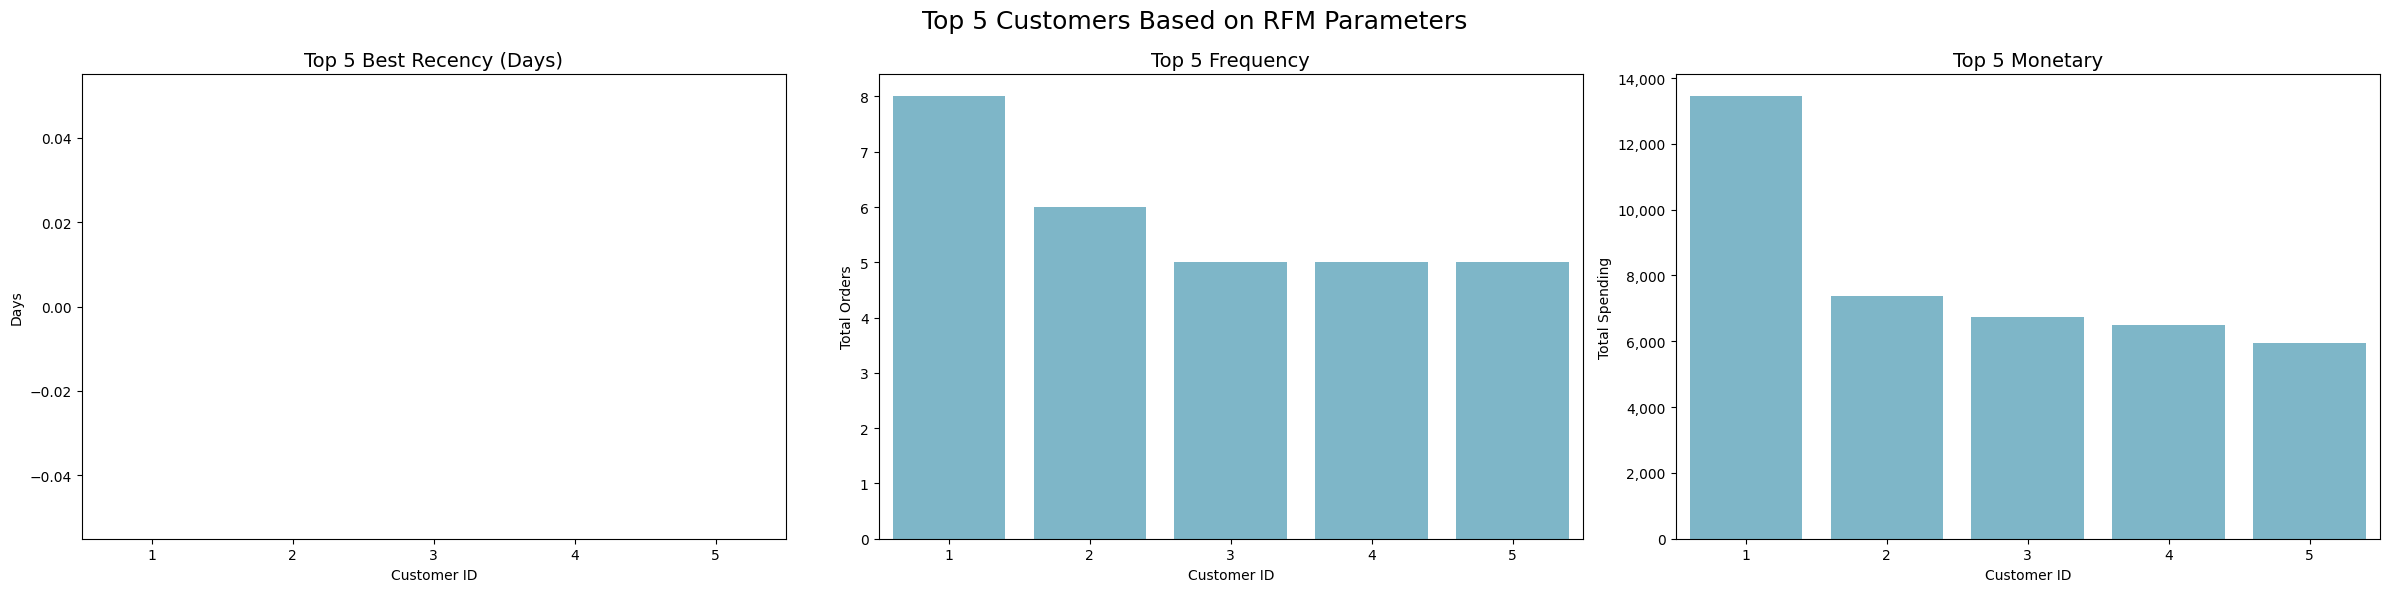

In [122]:
# membuat barchart untuk RFM analysis
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))

colors = ["#72BCD4"] * 5

# Top 5 Recency
top_recency = rfm_df.sort_values(by="recency", ascending=True).head(5).copy()
top_recency['rank'] = range(1, len(top_recency)+1)

sns.barplot(
    y="recency",
    x="rank",
    data=top_recency,
    palette=colors,
    ax=ax[0]
)
ax[0].set_title("Top 5 Best Recency (Days)", fontsize=14)
ax[0].set_xlabel("Customer ID")
ax[0].set_ylabel("Days")
ax[0].tick_params(axis='x', rotation=0)


# Top 5 Frequency
top_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5).copy()
top_frequency['rank'] = range(1, len(top_frequency)+1)

sns.barplot(
    y="frequency",
    x="rank",
    data=top_frequency,
    palette=colors,
    ax=ax[1]
)
ax[1].set_title("Top 5 Frequency", fontsize=14)
ax[1].set_xlabel("Customer ID")
ax[1].set_ylabel("Total Orders")
ax[1].tick_params(axis='x', rotation=0)


# Top 5 Monetary
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5).copy()
top_monetary['rank'] = range(1, len(top_monetary)+1)

sns.barplot(
    y="monetary",
    x="rank",
    data=top_monetary,
    palette=colors,
    ax=ax[2]
)
ax[2].set_title("Top 5 Monetary", fontsize=14)
ax[2].set_xlabel("Customer ID")
ax[2].set_ylabel("Total Spending")

# format monetary biar rapi
ax[2].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

ax[2].tick_params(axis='x', rotation=0)


plt.suptitle("Top 5 Customers Based on RFM Parameters", fontsize=18)

plt.tight_layout()
plt.show()

In [123]:
top_recency[['rank','customer_id','recency']]

,rank,customer_id,recency
24548,1,954374e93a9fe26229f11c514081053d,0
28603,2,addd42012ed67639f9e0d26155b7c2e1,0
36677,3,de3db263f702dd8fbb39bad7ccab5d62,0
32271,4,c3da934a20ea5e25e85e3a03cb0f0945,0
41707,5,fd900b490aa7416cdec68bc136bc3334,0


In [124]:
top_frequency[['rank','customer_id','frequency']]

,rank,customer_id,frequency
23194,1,8d50f5eadf50201ccdcedfb9e2ac8455,8
3161,2,12f5d6e1cbf93dafd9dcc19095df0b3d,6
16585,3,6469f99c1f9dfae7733b25662e7f1782,5
4529,4,1b6c7548a2a1f9037c1fd3ddfed95f33,5
11855,5,47c1a3033b8b77b3ab6e109eb4d5fdf3,5


In [125]:
top_monetary[['rank','customer_id','monetary']]

,rank,customer_id,monetary
1690,1,0a0a92112bd4c708ca5fde585afaa872,13440.0
35983,2,da122df9eeddfedc1dc1f5349a1a690c,7388.0
36349,3,dc4802a71eae9be1dd28f5d788ceb526,6735.0
42003,4,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
10550,5,4007669dec559734d6f53e029e360987,5934.6


**Insight:**

- Berdasarkan hasil analisis, pelanggan dengan peringkat teratas pada metrik recency memiliki nilai 0 hari, yang berarti mereka melakukan transaksi pada hari terakhir dalam dataset. Hal ini menunjukkan bahwa terdapat sejumlah pelanggan yang sangat aktif dan masih berinteraksi dengan platform hingga periode terbaru.

- Dari analisis frequency, terlihat bahwa terdapat pelanggan dengan jumlah transaksi hingga 8 kali. Selain itu, beberapa pelanggan lainnya juga menunjukkan frekuensi pembelian yang cukup tinggi, yaitu antara 5 hingga 6 kali transaksi.

- Berdasarkan analisis monetary, terdapat pelanggan dengan total pengeluaran yang sangat tinggi, mencapai lebih dari 13.000. Selain itu, beberapa pelanggan lainnya juga memiliki kontribusi pengeluaran yang signifikan, berkisar antara 5.900 hingga 6.700.


## Conclusion

Berdasarkan hasil analisis data yang telah dilakukan terhadap dataset e-commerce, diperoleh beberapa temuan penting terkait performa penjualan dan perilaku pelanggan.

- Conclution pertanyaan 1

  Dari sisi performa penjualan, terlihat bahwa jumlah transaksi dan revenue mengalami fluktuasi pada periode tertentu. Hal ini mengindikasikan adanya pola musiman atau faktor tertentu yang memengaruhi aktivitas pembelian pelanggan. Oleh karena itu, perusahaan perlu mengidentifikasi periode dengan performa tinggi untuk dimanfaatkan dalam strategi pemasaran.

- Conclution pertanyaan 2

  Berdasarkan analisis produk, ditemukan bahwa terdapat produk kategori yaitu bed bath table yang memiliki tingkat penjualan lebih tinggi dibandingkan lainnya. Produk ini berpotensi menjadi andalan perusahaan dan dapat diprioritaskan dalam strategi promosi maupun pengelolaan stok.

- Conclution pertanyaan 3

  Dari sisi geografis, distribusi pelanggan menunjukkan bahwa kota Sao Paulo memiliki jumlah transaksi yang lebih tinggi dibandingkan kota lainnya. Hal ini menunjukkan adanya konsentrasi pasar di wilayah tertentu yang dapat menjadi fokus dalam pengembangan strategi bisnis secara regional.

- Conclution pertanyaan 4 - 6

  Melalui analisis RFM (Recency, Frequency, Monetary), diperoleh pemahaman mengenai perilaku pelanggan berdasarkan aktivitas transaksi mereka. Terdapat pelanggan yang masih aktif dengan nilai recency rendah, pelanggan yang sering melakukan pembelian dengan nilai frequency tinggi, serta pelanggan dengan kontribusi pengeluaran yang besar berdasarkan nilai monetary.

  Hasil analisis ini menunjukkan bahwa setiap pelanggan memiliki karakteristik yang berbeda-beda. Oleh karena itu, perusahaan dapat memanfaatkan informasi ini untuk menyusun strategi yang lebih tepat, seperti mempertahankan pelanggan aktif, meningkatkan frekuensi pembelian pelanggan, serta memberikan perhatian khusus kepada pelanggan dengan kontribusi nilai transaksi yang tinggi.


Secara keseluruhan, analisis ini menunjukkan bahwa pemanfaatan data dapat memberikan insight yang berharga dalam memahami perilaku pelanggan dan meningkatkan performa bisnis. Dengan menerapkan strategi berbasis data, perusahaan diharapkan dapat meningkatkan kepuasan pelanggan, loyalitas, serta revenue secara berkelanjutan.